# Загрузка библиотек

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import sys
import os
import numpy
import matplotlib.pyplot as plt
import shap
import featurewiz
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, precision_recall_curve, roc_curve, accuracy_score, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC
from sklearn.utils import class_weight

Imported 0.2.6 version. Select nrows to a small number when running on huge datasets.
output = featurewiz(dataname, target, corr_limit=0.90, verbose=2, sep=',', 
		header=0, test_data='',feature_engg='', category_encoders='',
		dask_xgboost_flag=False, nrows=None, skip_sulov=False)
Create new features via 'feature_engg' flag : ['interactions','groupby','target']



In [3]:
sys.path.append('../utils_functionality/')
from data_analysis.split_analisys import *

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
RANDOM_STATE = 42

# Загрузка данных и разделение на train, test

In [6]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])
train, test = train_test_split(df, test_size=0.33, random_state=RANDOM_STATE)

# Моделирование

In [7]:
from featurewiz import featurewiz
from xgboost import XGBClassifier

class FeatureWizModel:
    def __init__(self, df, target, target_columns, verbose):
        self.target = target
        self.df = df.copy()
        self.verbose = verbose

    def feature_selection(self, corr_limit=0.7):
        self.feats, self.df_featurewiz = featurewiz(
            self.df, 
            self.target, 
            corr_limit=0.7, 
            verbose=self.verbose
        )


class CreateSamples:
    def __init__(self, df, train, test, target, features=None, use_featurewiz=False, corr_limit=0.7, verbose=0):
        self.target_columns=['splashing', 'breaking_up', 'net_impact', 'rebound']
        self.target = target
        drop_columns = list(set(self.target_columns) - set([target])) + ['test']
        self.df = df.drop(columns=drop_columns, axis=1).copy()
        self.features = features
        if use_featurewiz:
            fwiz = FeatureWizModel(
                            df=self.df, verbose=verbose, target=target, target_columns=self.target_columns, 
                        )
            fwiz.feature_selection(corr_limit)
            self.df, self.features = fwiz.df_featurewiz, fwiz.feats
        
        self.y = self.df[self.target]
        if self.features is not None:
            to_drop = set(self.df.columns) - set(self.features)
            self.X  = self.df.drop(to_drop, axis=1)
        else:
            self.X = self.df.drop(target, axis=1)
        self.X_train, self.y_train = self.X.loc[train.index], self.y[train.index]
        self.X_test, self.y_test = self.X.loc[test.index], self.y[test.index]
    
    def get_samples(self):
        return self.X_train, self.X_test, self.y_train, self.y_test
    
    
def get_classification_report(y_train, y_test, y_preds, y_preds_proba):
    from IPython.display import display, HTML
    display(HTML(f'<h2>ROC AUC: {roc_auc_score(y_test, y_preds):.4f}</h2>'))
    crep = pd.DataFrame(classification_report(y_test, y_preds, output_dict=True)).T
    display(HTML(crep.to_html()))


def get_shap_interpretation(model, X_train):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    shap.summary_plot(shap_values, X_train)
    plt.show()


def get_cv_results(model, X_train, y_train, X_test, y_test):
    kfold = KFold(n_splits=5, random_state=RANDOM_STATE, shuffle=True)
    train_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring="f1")
    print("F1 Train:\t%.2f%% (std: %.2f%%)" % (train_results.mean()*100, train_results.std()*100))

    test_results = cross_val_score(model, X_test, y_test, cv=kfold, scoring="f1")
    print("F1 Test:\t%.2f%% (std: %.2f%%)" % (test_results.mean()*100, test_results.std()*100))

## Baseline 1. Featurewiz + XGBoost

### Splashing

In [8]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [9]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.850746,0.876923,0.863636,65.000000
1,0.857143,0.827586,0.842105,58.000000
accuracy,0.853659,0.853659,0.853659,0.853659
macro avg,0.853945,0.852255,0.852871,123.000000
weighted avg,0.853763,0.853659,0.853483,123.000000


#### Cross-Validation

In [10]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	80.97% (std: 2.51%)
F1 Test:	79.55% (std: 5.16%)


#### SHAP interpretation

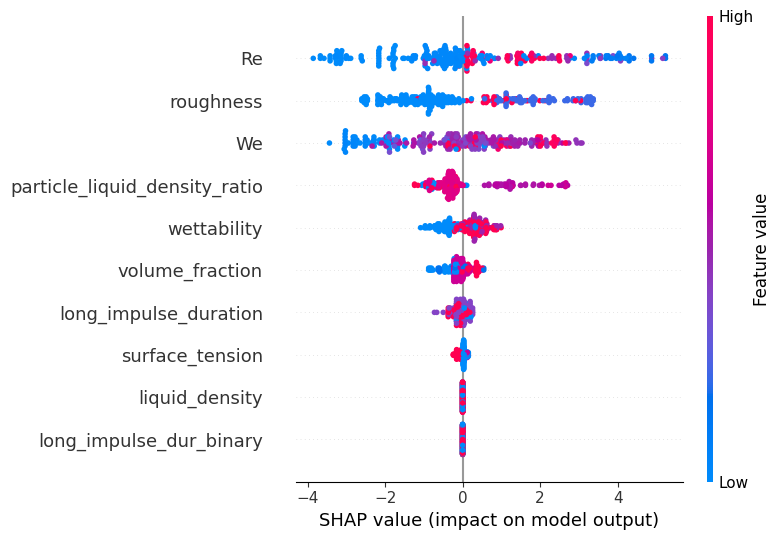

In [11]:
get_shap_interpretation(model, X_train)

#### Net impact

In [12]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [13]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.857143,0.951220,0.901734,82.000000
1,0.875000,0.682927,0.767123,41.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.866071,0.817073,0.834429,123.000000
weighted avg,0.863095,0.861789,0.856864,123.000000


In [14]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	70.84% (std: 7.44%)
F1 Test:	77.88% (std: 11.39%)


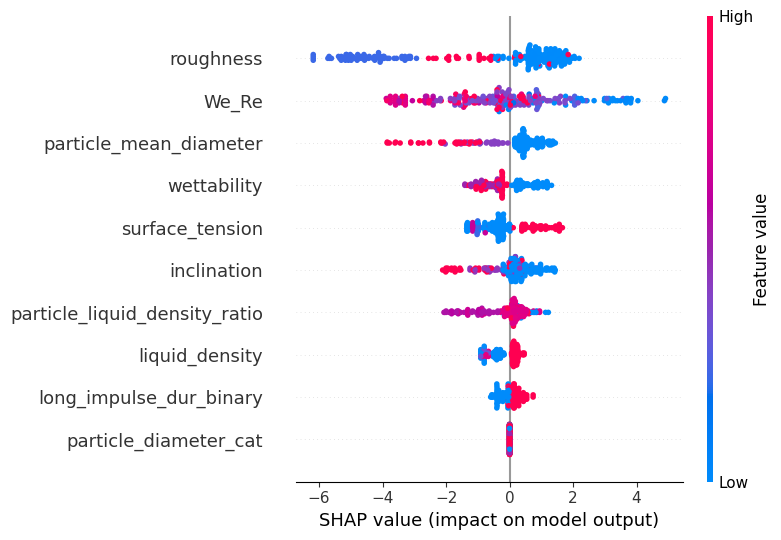

In [15]:
get_shap_interpretation(model, X_train)

## Baseline 2. Featurewiz + XGBoost

### Splashing

In [16]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [17]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [19]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.852941,0.892308,0.872180,65.000000
1,0.872727,0.827586,0.849558,58.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.862834,0.859947,0.860869,123.000000
weighted avg,0.862271,0.861789,0.861513,123.000000


#### Cross-Validation

In [20]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	84.66% (std: 4.54%)
F1 Test:	79.55% (std: 5.16%)


#### SHAP interpretation

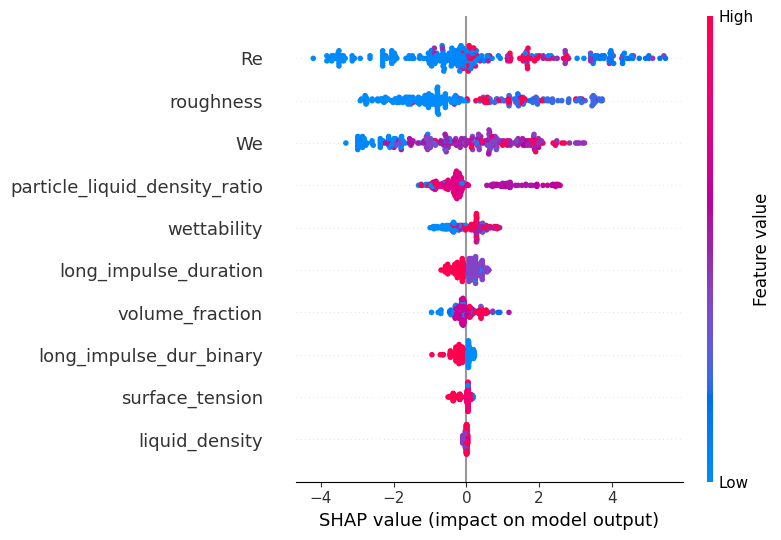

In [21]:
get_shap_interpretation(model, X_train)

### net_impact

In [22]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [23]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [24]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.866667,0.951220,0.906977,82.000000
1,0.878788,0.707317,0.783784,41.000000
accuracy,0.869919,0.869919,0.869919,0.869919
macro avg,0.872727,0.829268,0.845380,123.000000
weighted avg,0.870707,0.869919,0.865912,123.000000


#### Cross-Validation

In [25]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	86.62% (std: 4.67%)
F1 Test:	77.88% (std: 11.39%)


#### SHAP interpretation

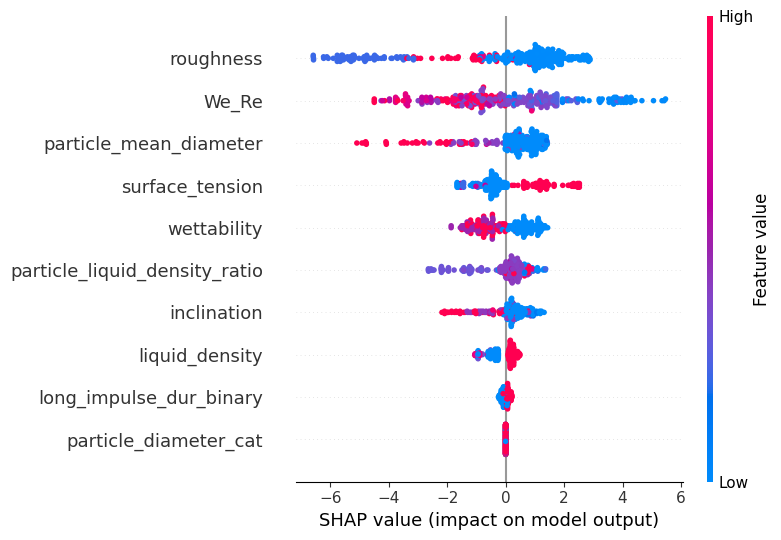

In [26]:
get_shap_interpretation(model, X_train)